# Brent Oil Price — Exploratory Data Analysis

Birhan Energies | Task 1 & 2 foundational EDA

This notebook loads the daily Brent crude oil price series (20-May-1987 to Nov-2022) and examines:

1. Trend over time
2. Stationarity of price levels vs. log returns
3. Volatility clustering / patterns

These properties directly motivate the Bayesian change point model in the companion notebook `change_point_model.ipynb`: since raw prices are non-stationary (a slow-moving, trending mean), a change point model on price levels captures **regime shifts in the mean price** driven by structural/geopolitical events, while log returns are used to characterise **volatility regimes**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

plt.rcParams["figure.figsize"] = (12, 5)
%matplotlib inline

## 1. Load data

The raw file mixes two date formats (`20-May-87` and `Apr 22, 2020`) starting partway through 2020, so we use pandas' mixed-format inference rather than a single `strptime` pattern.

In [2]:
df = pd.read_csv("../data/BrentOilPrices.csv")
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df = df.sort_values("Date").reset_index(drop=True)
df["LogPrice"] = np.log(df["Price"])
df["LogReturn"] = df["LogPrice"].diff()

print(f"Rows: {len(df)}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Rows: 9011
Date range: 1987-05-20 to 2022-11-14


,Date,Price,LogPrice,LogReturn
0,1987-05-20,18.63,2.924773,NaN
1,1987-05-21,18.45,2.915064,-0.009709
2,1987-05-22,18.55,2.920470,0.005405
3,1987-05-25,18.60,2.923162,0.002692
4,1987-05-26,18.63,2.924773,0.001612


## 2. Raw price series

Visually, the series shows several distinct regimes: a long calm period below $25/bbl through the late 1990s, a strong secular uptrend 2002-2008 ending in the 2008 financial-crisis spike and crash, a high-and-range-bound 2011-2014 plateau, the late-2014 OPEC-driven collapse, a COVID-19 crash to single digits in April 2020, and the 2022 Russia-Ukraine spike. These are exactly the kind of structural breaks a change point model is designed to detect.

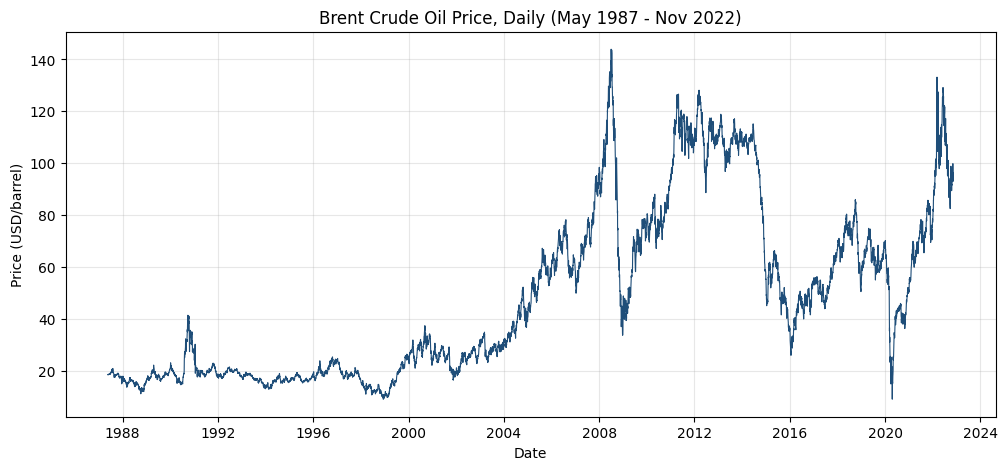

In [3]:
fig, ax = plt.subplots()
ax.plot(df["Date"], df["Price"], linewidth=0.8, color="#1f4e79")
ax.set_title("Brent Crude Oil Price, Daily (May 1987 - Nov 2022)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD/barrel)")
ax.grid(alpha=0.3)
plt.show()

## 3. Stationarity: price levels vs. log returns

We run the Augmented Dickey-Fuller (ADF, H0 = unit root / non-stationary) and KPSS (H0 = stationary) tests on both series. A raw price series with a random-walk-like trend is expected to fail ADF (fail to reject unit root) and fail KPSS (reject stationarity), while log returns — the day-over-day percentage change — should look stationary on both tests. This matters for modeling choice: a change point model applied directly to a non-stationary price series is estimating shifts in a moving target, so we interpret it as detecting **mean-level regime shifts**, whereas a change point model on log returns would instead be detecting shifts in **volatility regime**.

In [4]:
def stationarity_report(series: pd.Series, label: str) -> None:
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
    print(f"--- {label} ---")
    print(f"ADF statistic={adf_stat:.3f}, p-value={adf_p:.4f} -> {'stationary' if adf_p < 0.05 else 'NON-stationary'}")
    print(f"KPSS statistic={kpss_stat:.3f}, p-value={kpss_p:.4f} -> {'stationary' if kpss_p > 0.05 else 'NON-stationary'}")
    print()

stationarity_report(df["Price"], "Price level")
stationarity_report(df["LogReturn"], "Log return")

C:\Users\maedo\AppData\Local\Temp\ipykernel_17148\2674056374.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")


--- Price level ---
ADF statistic=-1.994, p-value=0.2893 -> NON-stationary
KPSS statistic=9.559, p-value=0.0100 -> NON-stationary



--- Log return ---
ADF statistic=-16.427, p-value=0.0000 -> stationary
KPSS statistic=0.034, p-value=0.1000 -> stationary



C:\Users\maedo\AppData\Local\Temp\ipykernel_17148\2674056374.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")


**Result:** ADF fails to reject the unit-root null for price levels (p ≈ 0.29) and KPSS rejects stationarity (p ≈ 0.01) — price levels are non-stationary, confirming the visual trending behaviour. Log returns are stationary on both tests (ADF p ≈ 0, KPSS p > 0.05).

## 4. Log returns and volatility clustering

Log returns are computed as `log(price_t) - log(price_{t-1})`. Plotting them reveals **volatility clustering**: large moves (in either direction) tend to bunch together in time — visible around 1990-91 (Gulf War), 2008-09 (financial crisis), 2014-16 (oil glut), and 2020 (COVID-19) — rather than being spread uniformly. This is a classic stylised fact of financial time series and is a motivation for GARCH-family or regime-switching volatility models as a possible extension (see Task 2 'Advanced Extensions').

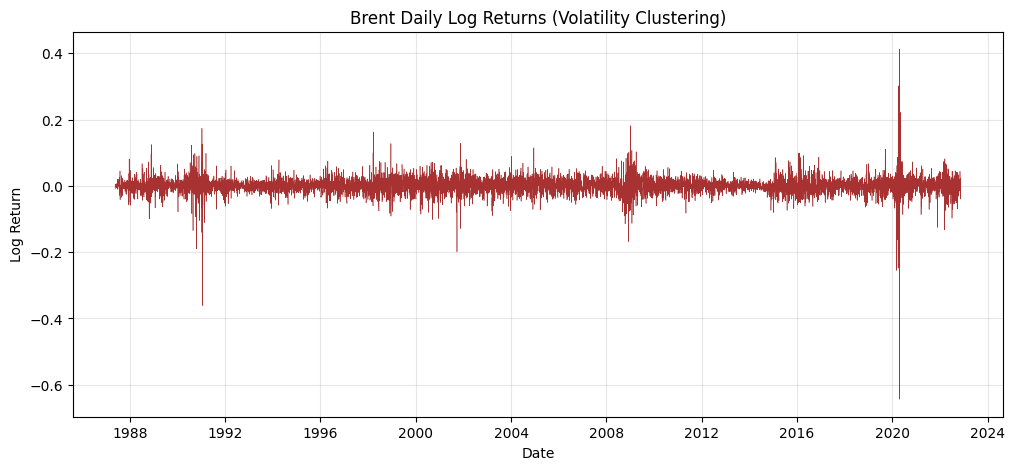

In [5]:
fig, ax = plt.subplots()
ax.plot(df["Date"], df["LogReturn"], linewidth=0.4, color="#a83232")
ax.set_title("Brent Daily Log Returns (Volatility Clustering)")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
ax.grid(alpha=0.3)
plt.show()

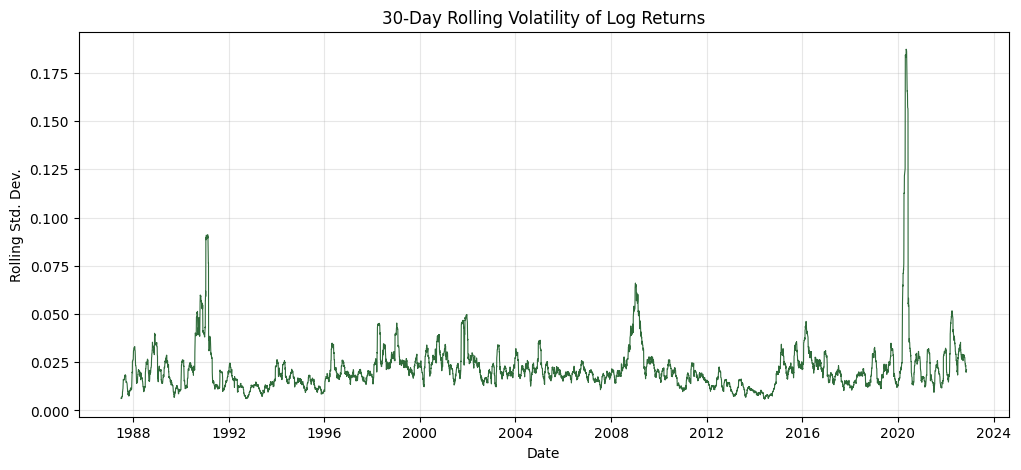

In [6]:
window = 30
rolling_std = df["LogReturn"].rolling(window).std()

fig, ax = plt.subplots()
ax.plot(df["Date"], rolling_std, linewidth=0.8, color="#2f6b3a")
ax.set_title(f"{window}-Day Rolling Volatility of Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Std. Dev.")
ax.grid(alpha=0.3)
plt.show()

## 5. Distribution shape

Log returns are strongly leptokurtic (fat-tailed) and slightly left-skewed relative to a normal distribution — large negative shocks (crashes) are more extreme and more frequent than large positive ones. This has an implication for the Bayesian model in Task 2: a Normal likelihood is a reasonable, tractable starting point for the mean-shift change point model, but a Student-t likelihood would better accommodate the fat tails if extended to model returns directly.

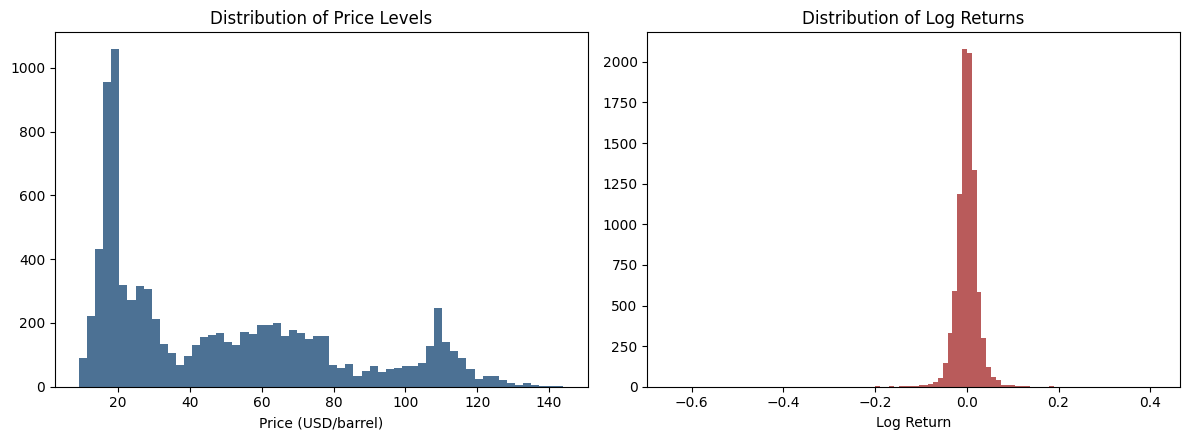

Log return skew: -1.744
Log return excess kurtosis: 65.905


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df["Price"], bins=60, color="#1f4e79", alpha=0.8)
axes[0].set_title("Distribution of Price Levels")
axes[0].set_xlabel("Price (USD/barrel)")
axes[1].hist(df["LogReturn"].dropna(), bins=100, color="#a83232", alpha=0.8)
axes[1].set_title("Distribution of Log Returns")
axes[1].set_xlabel("Log Return")
plt.tight_layout()
plt.show()

print(f"Log return skew: {df['LogReturn'].skew():.3f}")
print(f"Log return excess kurtosis: {df['LogReturn'].kurtosis():.3f}")

## 6. Summary of findings and modeling implications

| Property | Finding | Modeling implication |
|---|---|---|
| Trend | Multiple distinct regimes / structural breaks, no single stable mean | Justifies a change point (not single-regime) model |
| Stationarity (price) | Non-stationary (ADF fails to reject unit root, KPSS rejects stationarity) | A change point model on price levels detects **mean-level shifts**, not shifts around a fixed long-run mean |
| Stationarity (log returns) | Stationary on both tests | Log returns are appropriate for volatility-regime analysis and any future ARIMA/GARCH modeling |
| Volatility | Strong clustering, fat left tail | Motivates Student-t likelihoods or explicit volatility-regime (Markov-switching) models as extensions |

Next step (Task 2): fit a Bayesian change point model (PyMC) with a discrete uniform prior on the switch point `tau` and two regime means `mu_1`, `mu_2`, then cross-reference detected change points against `data/events.csv`.